Jaccard PERMANOVA results:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1269
number of groups                  2
test statistic             11.12976
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


/usr/local/lib/python3.10/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.21087010448269966 and the largest is 29.35726642171943.
  warn(
<ipython-input-7-ee2adeaeffb6>:79: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ellipse = Ellipse(mean, width, height, np.degrees(theta), edgecolor=color, facecolor='none', **kwargs)


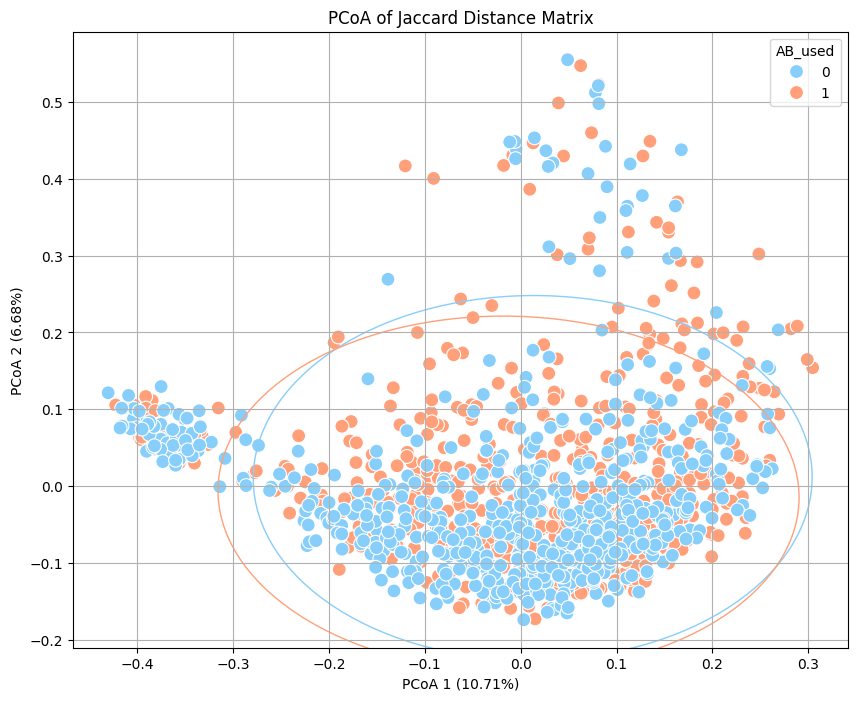

In [ ]:
import pandas as pd
import numpy as np
from skbio.stats.distance import permanova
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse


df = pd.read_csv('final_input.csv')

X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']
sample_names = df['sample-name']

# Check for NaN values and remove corresponding rows
nan_indices = X.isna().any(axis=1)
X_clean = X[~nan_indices]
y_clean = y[~nan_indices]
sample_names_clean = sample_names[~nan_indices]

metadata = pd.DataFrame({'sample-name': sample_names_clean, 'AB_used': y_clean})
distance_matrix = beta_diversity("jaccard", X_clean.values, ids=sample_names_clean.values)


metadata = metadata.set_index('sample-name').reindex(distance_matrix.ids)

permanova_results = permanova(distance_matrix, metadata['AB_used'], permutations=999)
print('Jaccard PERMANOVA results:')
print(permanova_results)


pcoa_results = pcoa(distance_matrix)
pcoa_df = pd.DataFrame(pcoa_results.samples, index=distance_matrix.ids)


pcoa_df['AB_used'] = metadata['AB_used'].values

# Function to draw ellipses
def plot_ellipse(ax, data, color, n_std=1.96, **kwargs):
    if len(data) < 2:
        return

    cov = np.cov(data, rowvar=False)
    mean = np.mean(data, axis=0)

    eigvals, eigvecs = np.linalg.eigh(cov)

    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    vx, vy = eigvecs[:, 0][0], eigvecs[:, 0][1]
    theta = np.arctan2(vy, vx)
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(mean, width, height, np.degrees(theta), edgecolor=color, facecolor='none', **kwargs)
    ax.add_patch(ellipse)

# Plot the PCoA results with ellipses
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(x=pcoa_df.iloc[:, 0], y=pcoa_df.iloc[:, 1], hue=pcoa_df['AB_used'], palette=['#87CEFA', '#FFA07A'], s=100)

# Plot ellipses for each group
for group, color in zip(pcoa_df['AB_used'].unique(), ['#87CEFA', '#FFA07A']):
    data = pcoa_df[pcoa_df['AB_used'] == group].iloc[:, :2].values
    plot_ellipse(ax, data, color=color)

plt.title('PCoA of Jaccard Distance Matrix')
plt.xlabel(f'PCoA 1 ({pcoa_results.proportion_explained[0]:.2%})')
plt.ylabel(f'PCoA 2 ({pcoa_results.proportion_explained[1]:.2%})')
plt.legend(title='AB_used')
plt.grid(True)
plt.show()
